## Option Data Download

In [1]:
# from fetch_option_data import fetch_data_by_month
# fetch_data_by_month("MU", "2016-01-01", "2026-03-15")

## Bcaktesting the Wheel Strategy

In [24]:
from backtest import run_wheel_backtest
from report import WheelPerformanceReport

symbol = "SPY"

result = run_wheel_backtest(
    symbol=symbol,
    start_date="2016-03-15",
    end_date="2026-03-15",
    target_delta=0.25,
    stop_loss_multiple=1.5,
    # take_profit_multiple=0.3,
    put_exp_days=12,
    call_exp_days=0,
    initial_cash=5000,
    leverage=10,
)

report = WheelPerformanceReport(result)

In [25]:
report.summary_table()

,Value
Metric,
Symbol,SPY
Start Date,2016-03-15
End Date,2026-03-13
Initial Cash,"$5,000.00"
Ending Equity,"$22,048.25"
Net Profit,"$17,048.25"
Total Return,340.96%
CAGR,16.01%
Sharpe,1.56


In [26]:
report.trade_breakdown_table()

,legs,total_premium,avg_premium,avg_roi,avg_iv,avg_abs_delta,avg_moneyness,avg_days_held
type,,,,,,,,
put,384,"$80,414.00",$209.41,0.14%,18.83%,0.25,-2.29%,8.21


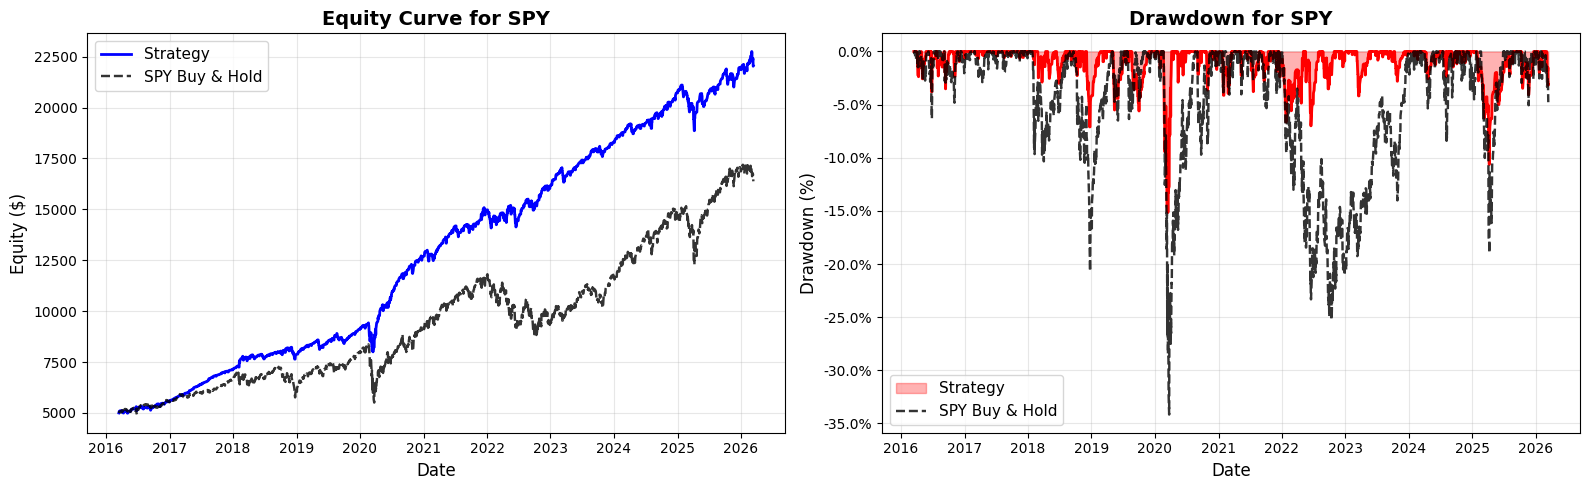

In [27]:
_ = report.plot_equity_and_drawdown()

In [28]:
from IPython.display import HTML, display

def display_long_df(df, max_height=400, max_width='100%'):
    html = (
        f"<div style='max-height:{max_height}px; overflow:auto; width:{max_width}; padding:5px;'>"
        f"{df.to_html(escape=False, index=False)}"
        f"</div>"
    )
    display(HTML(html))

display_long_df(result.trades)

date,side,type,strike,expiration,premium_per_share,premium,delta,leverage_ratio,moneyness,iv,outcome,days_held,ROI%,cash_flow,liquidation_cost,nav,exec_spot,spot,buyback_price_per_share,stop_trigger_price_per_share,stop_open_price_per_share
2016-03-15,short,put,197.0,2016-03-31,1.165000,116.500000,-0.266940,3.940000,-2.557254,0.165285,expired,16,0.591371,116.500000,NaN,5116.500000,202.170,205.780,NaN,NaN,NaN
2016-04-01,short,put,203.5,2016-04-15,0.700000,70.000000,-0.237901,3.977328,-1.676571,0.122107,cut_loss,4,-0.334152,-68.000000,NaN,5048.500000,206.970,204.350,1.3800,1.68,1.38
2016-04-06,short,put,202.5,2016-04-22,0.850000,85.000000,-0.241811,4.011092,-1.913296,0.135505,cut_loss,1,-0.222222,-45.000000,NaN,5003.500000,206.450,203.920,1.3000,2.17,1.30
2016-04-08,short,put,200.5,2016-04-22,0.870000,87.000000,-0.243056,4.007195,-1.955990,0.148588,expired,14,0.433915,87.000000,NaN,5090.500000,204.500,208.957,NaN,NaN,NaN
2016-04-25,short,put,204.5,2016-05-13,0.985000,98.500000,-0.252787,4.017287,-1.953264,0.138027,cut_loss,4,-0.240831,-49.250000,NaN,5041.250000,208.574,206.510,1.4775,2.12,1.42
2016-05-02,short,put,203.5,2016-05-20,1.060000,106.000000,-0.252161,4.036697,-2.121110,0.149275,cut_loss,1,-0.260442,-53.000000,NaN,4988.250000,207.910,206.150,1.5900,1.94,1.51
2016-05-04,short,put,200.5,2016-05-20,1.065000,106.500000,-0.246150,4.019446,-2.290448,0.166251,expired,16,0.531172,106.500000,NaN,5094.750000,205.200,205.570,NaN,NaN,NaN
2016-05-23,short,put,200.5,2016-06-10,0.975000,97.500000,-0.240491,3.935424,-2.218971,0.148288,expired,18,0.486284,97.500000,NaN,5192.250000,205.050,210.150,NaN,NaN,NaN
2016-06-13,short,put,201.0,2016-06-30,1.655000,165.500000,-0.256452,3.871154,-3.564746,0.231401,cut_loss,11,-0.411692,-82.750000,NaN,5109.500000,208.430,202.630,2.4825,7.28,2.22
2016-06-27,short,put,192.0,2016-07-15,1.680000,168.000010,-0.249429,3.757706,-3.488489,0.248060,expired,18,0.875000,168.000010,NaN,5277.500010,198.940,215.640,NaN,NaN,NaN


## Grid Search for Hyperparameter Optimization

In [19]:
import pandas as pd
from grid_search import run_grid_search

# grid_results = run_grid_search(
#     symbol=symbol,
#     start_date="2016-03-15",
#     end_date="2026-03-15",
#     initial_cash=8_000,
#     leverage=10,
#     max_workers=5,
# )

In [20]:
grid_results = pd.read_csv("data/grid_search/grid_results.csv")
display_long_df(grid_results[["case", "cagr", "sharpe", "max_drawdown"]].sort_values(by=["sharpe", "cagr"], ascending=False))

case,cagr,sharpe,max_drawdown
"delta=0.1, stop=1.5, put_dte=10",0.071253,1.833798,-0.048264
"delta=0.2, stop=1.5, put_dte=12",0.112261,1.709035,-0.070802
"delta=0.1, stop=3.0, put_dte=12",0.087050,1.693301,-0.054012
"delta=0.15, stop=1, put_dte=10",0.078980,1.637382,-0.087663
"delta=0.2, stop=1.5, put_dte=10",0.098685,1.606932,-0.131038
"delta=0.1, stop=2.0, put_dte=10",0.066066,1.589148,-0.086422
"delta=0.25, stop=1.5, put_dte=12",0.120992,1.542483,-0.114862
"delta=0.1, stop=4.0, put_dte=12",0.094997,1.500592,-0.100739
"delta=0.1, stop=1.5, put_dte=14",0.076383,1.492588,-0.068416
"delta=0.15, stop=1, put_dte=30",0.071159,1.465379,-0.088260


In [21]:
# grid_results_qqq = run_grid_search(
#     symbol="QQQ",
#     start_date="2016-03-15",
#     end_date="2026-03-15",
#     initial_cash=8_000,
#     leverage=10,
#     max_workers=5,
# )

In [22]:
grid_results_qqq = pd.read_csv("data/grid_search/grid_results_qqq.csv")
display_long_df(grid_results_qqq[["case", "cagr", "sharpe", "max_drawdown"]].sort_values(by=["sharpe", "cagr"], ascending=False))

case,cagr,sharpe,max_drawdown
"delta=0.1, stop=2.0, put_dte=3",0.066799,1.595678,-0.083482
"delta=0.1, stop=1, put_dte=3",0.059632,1.545383,-0.081437
"delta=0.1, stop=1.5, put_dte=3",0.057054,1.393252,-0.109120
"delta=0.2, stop=1.5, put_dte=10",0.093435,1.317946,-0.092965
"delta=0.2, stop=1, put_dte=10",0.082434,1.282008,-0.121029
"delta=0.15, stop=1.5, put_dte=3",0.074241,1.276847,-0.130227
"delta=0.25, stop=1, put_dte=10",0.097165,1.270579,-0.197436
"delta=0.1, stop=3.0, put_dte=3",0.066298,1.261268,-0.095013
"delta=0.15, stop=1, put_dte=10",0.071982,1.236549,-0.112472
"delta=0.1, stop=1.5, put_dte=12",0.064622,1.228882,-0.098153


In [23]:
from pathlib import Path

data_dir = Path("data/gird_search")
data_dir.mkdir(parents=True, exist_ok=True)

grid_results.to_csv(data_dir / "grid_results.csv", index=False)
grid_results_qqq.to_csv(data_dir / "grid_results_qqq.csv", index=False)